# Homework Assignment for Week 2
## by Saikathir.S, Grade IX-A1
## House Price Predictor


# Setup

Importing `pandas`, loading the dataset, Checking datatypes, etc.

In [ ]:
import pandas as pd

# The dataset has been uploaded to session storage.
# We can now refer to it directly by its filename.
url = 'Housing.csv'
df = pd.read_csv(url)
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [ ]:

df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


In [ ]:
df.shape

(545, 13)

# Cleaning

Removing Duplicates (there isn't any), Cleaning Null Values (there isn't any), Type Conversion.

In [ ]:
df.isna().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
clean = df.dropna()

In [ ]:
clean.shape

(545, 13)

As the code already has 0 null values, move on to cleaning duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

Seems to not have any duplicates, dropping anyway

In [ ]:
df = df.drop_duplicates()

Dataset cleansed (I Think)

In [ ]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df[col] = df[col].apply(lambda x: 1 if x == 'yes' else 0)

print("Binary columns converted:")
display(df[binary_cols].head())

Binary columns converted:


,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0


In [ ]:
print("'furnishingstatus':")
display(df.head())

'furnishingstatus':


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,0,0,0,0,0,2,0,False,False
1,12250000,8960,4,4,4,0,0,0,0,0,3,0,False,False
2,12250000,9960,3,2,2,0,0,0,0,0,2,0,True,False
3,12215000,7500,4,2,2,0,0,0,0,0,3,0,False,False
4,11410000,7420,4,1,2,0,0,0,0,0,2,0,False,False


In [ ]:

display(df.dtypes)

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,int64
guestroom,int64
basement,int64
hotwaterheating,int64
airconditioning,int64


Type converted (Still have doubts though)

### Outlier Handling using IQR Method

To handle outliers, we will use the Interquartile Range (IQR) method. This involves:
1.  Calculating the first quartile (Q1) and third quartile (Q3).
2.  Determining the IQR (Q3 - Q1).
3.  Calculating the lower bound (Q1 - 1.5 * IQR) and upper bound (Q3 + 1.5 * IQR).
4.  Any values below the lower bound or above the upper bound will be considered outliers. We will cap these outliers by setting values below the lower bound to the lower bound, and values above the upper bound to the upper bound.

In [ ]:
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    print(f"Outliers in '{column}' capped. Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
    return df

# Handle outliers for 'price' column
df = cap_outliers_iqr(df, 'price')

# Handle outliers for 'area' column
df = cap_outliers_iqr(df, 'area')

print("\nDescriptive statistics after outlier capping:")
display(df[['price', 'area']].describe())

Outliers in 'price' capped. Lower bound: -35000.00, Upper bound: 9205000.00
Outliers in 'area' capped. Lower bound: -540.00, Upper bound: 10500.00

Descriptive statistics after outlier capping:


,price,area
count,5.450000e+02,545.000000
mean,4.727388e+06,5102.249541
std,1.745227e+06,2005.804353
min,1.750000e+06,1650.000000
25%,3.430000e+06,3600.000000
50%,4.340000e+06,4600.000000
75%,5.740000e+06,6360.000000
max,9.205000e+06,10500.000000


In [ ]:
import numpy as np

# Apply log transformation to 'price' (target variable)
df['price'] = np.log1p(df['price'])
print("Log transformation applied to 'price' column.")

# Apply log transformation to 'area' (feature)
df['area'] = np.log1p(df['area'])
print("Log transformation applied to 'area' column.")

print("\nFirst 5 rows of DataFrame after log transformation:")
display(df.head())

Log transformation applied to 'price' column.
Log transformation applied to 'area' column.

First 5 rows of DataFrame after log transformation:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,16.035257,8.912069,4,2,3,0,0,0,0,0,2,0,False,False
1,16.035257,9.100637,4,4,4,0,0,0,0,0,3,0,False,False
2,16.035257,9.206433,3,2,2,0,0,0,0,0,2,0,True,False
3,16.035257,8.922792,4,2,2,0,0,0,0,0,3,0,False,False
4,16.035257,8.912069,4,1,2,0,0,0,0,0,2,0,False,False


# Training

train_test_split, Test evaluation, basically everything to do with `scikit-learn`.

In [ ]:
x = df[['area',	'bedrooms',	'bathrooms', 'stories', 'mainroad', 'guestroom',	'basement', 'hotwaterheating', 'airconditioning', 'parking',	'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']]
y = df['price']

print(x.shape)
print(y.shape)

(545, 13)
(545,)


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,        # 20% for test
    random_state=42       # reproducibility — same split every run
)

print(x_train.shape)
print(x_test.shape)

(436, 13)
(109, 13)


In [ ]:
from sklearn.linear_model import LinearRegression   # 1. import
import numpy as np

model = LinearRegression()                            # 2. instantiate
model.fit(x_train, y_train)                           # 3. fit (= train)
preds  = model.predict(x_test)                        # 4. predict

from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(y_test, preds)        # lower is better
mae = mean_absolute_error(y_test, preds)        # easier to read (no squaring)
print('MSE= ',mse)
print('MAE= ',mae)
print('RMSE= ',np.sqrt(mse))
print('R-squared score=', model.score(x_test, y_test))                           # → R² for regression

MSE=  0.075182361787692
MAE=  0.21870157840868212
RMSE=  0.27419402215893035
R-squared score= 0.579644012182843


**Barely** above 0.5. I'll take it.

# Visualisation

Visualising test result graphs with `matplotlib` and `seaborn`.

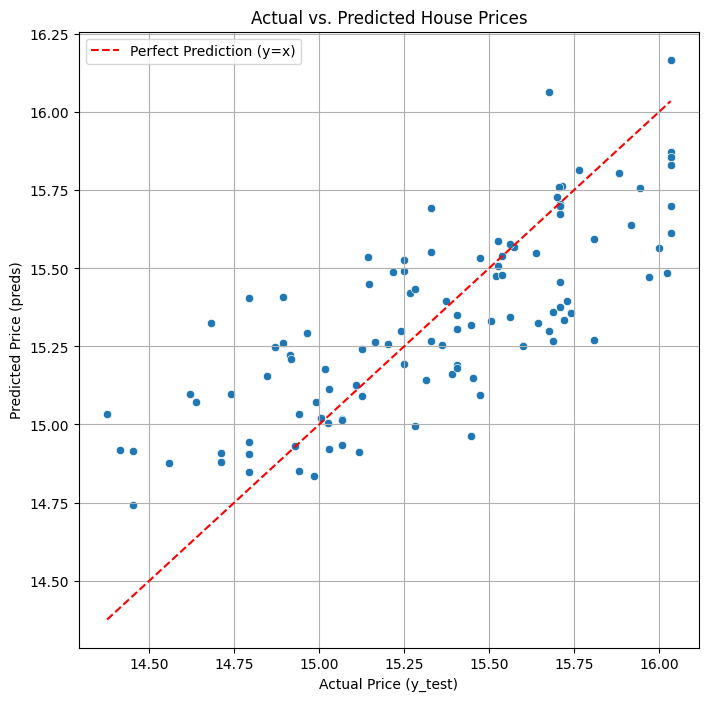

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction (y=x)')
plt.xlabel('Actual Price (y_test)')
plt.ylabel('Predicted Price (preds)')
plt.title('Actual vs. Predicted House Prices')
plt.legend()
plt.grid(True)
plt.show()

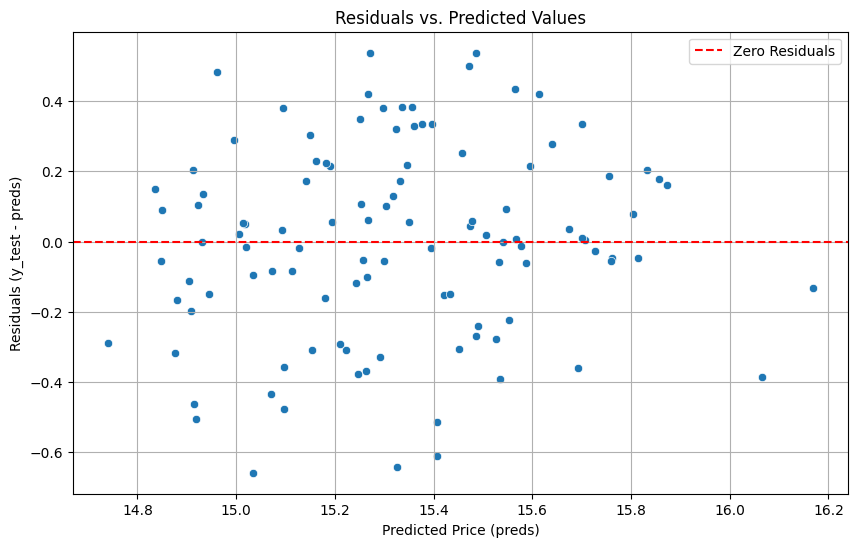

In [ ]:
residuals = y_test - preds

plt.figure(figsize=(10, 6))
sns.scatterplot(x=preds, y=residuals)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Residuals')
plt.xlabel('Predicted Price (preds)')
plt.ylabel('Residuals (y_test - preds)')
plt.title('Residuals vs. Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

Looks random, means everything works fine!

# Inspecting features and learned coefficients.

Making sure the predictions are actually sensible.

In [ ]:
coefficients_df = pd.DataFrame({'Feature': x.columns, 'Coefficient': model.coef_})
display(coefficients_df.sort_values(by='Coefficient', ascending=False))

,Feature,Coefficient
0,area,3.894635e-01
2,bathrooms,1.850866e-01
3,stories,8.667546e-02
9,parking,4.006349e-02
1,bedrooms,3.613218e-02
4,mainroad,9.714451e-17
5,guestroom,1.387779e-17
7,hotwaterheating,0.000000e+00
6,basement,0.000000e+00
8,airconditioning,0.000000e+00


### Feature Impact Analysis

The feature with the largest positive impact on the log-transformed price is `area` with a coefficient of approximately `0.389`. This makes real-world sense as houses with larger areas generally have higher prices, which is common in real-estate markets.